
# 02 — XGBoost Baseline (Lexical Features, GPU)
> Same 11 lexical numbers as RF, but gradient boosting — will use RTX 3050 `gpu_hist` if `use_gpu=True`. Senior plots identical to RF for fair comparison.<br>
> **Data:** `data/processed/train.csv` (1,259,799) → train, `val_unseen.csv` (23,998) → validation on **new families only** (LFO). Test-unseen is **never touched** here.<br>
> **Hardware:** RTX 3050 (8GB) — RF CPU, XGBoost `gpu_hist` if `--use-gpu`.<br>
> **Outputs:** `training/weights/<model>_best.pkl` + `training/figures/<model>_*.png` + metrics printed in notebook.


In [1]:

import numpy as np, pandas as pd, pathlib, json, math, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, f1_score, accuracy_score
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi":150, "savefig.dpi":300, "font.size":11})

BASE = Path(r"G:\dga_killer")
DATA_PROC = BASE / "data" / "processed"
FIG_DIR = BASE / "training" / "figures"
WEIGHTS_DIR = BASE / "training" / "weights"
FIG_DIR.mkdir(parents=True, exist_ok=True); WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

SEED=42
USE_GPU=True  # set False to force CPU hist
COLORS={"benign":"#2ecc71","dga":"#e74c3c","wordlist":"#3498db","nonwordlist":"#e67e22"}
print(f"USE_GPU={USE_GPU} — XGBoost will try device='cuda' then fallback to gpu_hist / hist")


USE_GPU=True — XGBoost will try device='cuda' then fallback to gpu_hist / hist


In [2]:

train = pd.read_csv(DATA_PROC / "train.csv")
val = pd.read_csv(DATA_PROC / "val_unseen.csv")
print(f"Train {train.shape}  Val {val.shape}")
train.head(2)


Train (1259799, 10)  Val (23998, 10)


,domain_raw,sld,sld_len,family,split,label,label_binary,wordlist,is_benign,has_non_ascii
0,thisthethemtheiritof.biz,thisthethemtheiritof,20,rovnix,train,dga,1,True,False,False
1,yfbay.com,yfbay,5,legit,train,benign,0,False,True,False



## 1. Features — identical to RF (11 lexical)


(1259799, 11) (23998, 11)


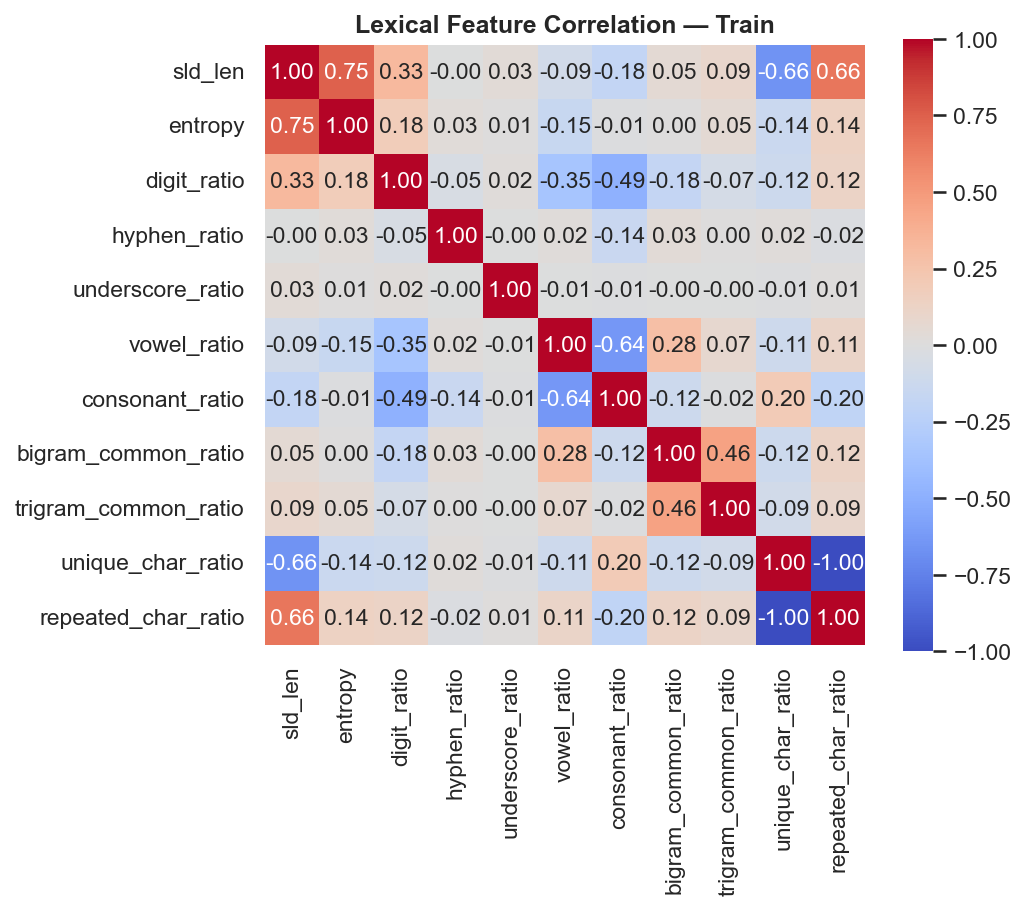

In [3]:

def shannon(s):
    s=str(s)
    if not s: return 0
    cnt=Counter(s)
    n=len(s)
    return -sum((c/n)*math.log2(c/n) for c in cnt.values())
def ngram_common(s,n=2):
    s=str(s).lower()
    if len(s)<n: return 0
    common={"th","he","in","er","an","re","on","at","en","nd"} if n==2 else {"the","ing","and","her","ere"}
    grams=[s[i:i+n] for i in range(len(s)-n+1)]
    return sum(1 for g in grams if g in common)/len(grams) if grams else 0
def extract_features(df):
    s=df["sld"].fillna("").astype(str)
    sl=s.str.lower()
    feats=pd.DataFrame({
        "sld_len": s.str.len(),
        "entropy": s.apply(shannon),
        "digit_ratio": s.apply(lambda x: sum(c.isdigit() for c in x)/len(x) if x else 0),
        "hyphen_ratio": s.str.count("-")/s.str.len().replace(0,1),
        "underscore_ratio": s.str.count("_")/s.str.len().replace(0,1),
        "vowel_ratio": sl.apply(lambda x: sum(c in "aeiou" for c in x)/len(x) if x else 0),
        "consonant_ratio": sl.apply(lambda x: sum(c in "bcdfghjklmnpqrstvwxyz" for c in x)/len(x) if x else 0),
        "bigram_common_ratio": s.apply(lambda x: ngram_common(x,2)),
        "trigram_common_ratio": s.apply(lambda x: ngram_common(x,3)),
        "unique_char_ratio": s.apply(lambda x: len(set(x))/len(x) if x else 0),
        "repeated_char_ratio": s.apply(lambda x: 1-len(set(x))/len(x) if x else 0),
    })
    return feats.fillna(0).replace([np.inf,-np.inf],0)

FEATURE_COLS=["sld_len","entropy","digit_ratio","hyphen_ratio","underscore_ratio","vowel_ratio","consonant_ratio","bigram_common_ratio","trigram_common_ratio","unique_char_ratio","repeated_char_ratio"]
X_train=extract_features(train); y_train=train["label_binary"].values
X_val=extract_features(val); y_val=val["label_binary"].values
print(X_train.shape, X_val.shape)
# Correlation heatmap
corr=X_train.corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Lexical Feature Correlation — Train", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG_DIR/"xgb_correlation.png", bbox_inches="tight"); plt.show()



## 2. Train — XGBoost (400 trees, depth 8, lr 0.05)
RTX 3050 will use `device='cuda'` or `gpu_hist` — falls back to CPU if no GPU.


In [4]:

import xgboost as xgb
print(f"xgboost {xgb.__version__}")
# Try GPU, fallback to CPU — keeps notebook runnable anywhere
model=None
if USE_GPU:
    try:
        model=xgb.XGBClassifier(n_estimators=400, max_depth=8, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=SEED, tree_method="hist", device="cuda", verbosity=1)
        print("Trying device='cuda'...")
        # quick fit on tiny slice to test GPU
        model.fit(X_train[:1000], y_train[:1000], verbose=False)
        model=xgb.XGBClassifier(n_estimators=400, max_depth=8, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=SEED, tree_method="hist", device="cuda", verbosity=1)
    except Exception as e:
        print(f"CUDA device failed ({e}), trying gpu_hist...")
        try:
            model=xgb.XGBClassifier(n_estimators=400, max_depth=8, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=SEED, tree_method="gpu_hist", predictor="gpu_predictor", verbosity=1)
            model.fit(X_train[:1000], y_train[:1000], verbose=False)
        except Exception as e2:
            print(f"gpu_hist also failed ({e2}), falling back to CPU hist")
            model=xgb.XGBClassifier(n_estimators=400, max_depth=8, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=SEED, tree_method="hist", n_jobs=-1, verbosity=1)
else:
    model=xgb.XGBClassifier(n_estimators=400, max_depth=8, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=SEED, tree_method="hist", n_jobs=-1, verbosity=1)

print(f"Fitting XGBoost on {X_train.shape} (RTX 3050, ~15-25 min)...")
model.fit(X_train, y_train, verbose=100)
print("Done. Best iteration:", getattr(model, "best_iteration", "N/A"))


xgboost 3.4.1
Trying device='cuda'...


Fitting XGBoost on (1259799, 11) (RTX 3050, ~15-25 min)...


Done. Best iteration: N/A



## 3. Evaluate — Train & Val-Unseen (every metric + curves)



TRAIN


              precision    recall  f1-score   support

      benign      0.788     0.870     0.827    629852
         dga      0.855     0.767     0.809    629947

    accuracy                          0.818   1259799
   macro avg      0.822     0.818     0.818   1259799
weighted avg      0.822     0.818     0.818   1259799



Accuracy 0.8185 | F1 0.8085 | ROC-AUC 0.9015 | PR-AUC 0.9165

VAL-UNSEEN (6 new families)
              precision    recall  f1-score   support

      benign      0.620     0.871     0.724     11999
         dga      0.784     0.465     0.584     11999

    accuracy                          0.668     23998
   macro avg      0.702     0.668     0.654     23998
weighted avg      0.702     0.668     0.654     23998

Accuracy 0.6684 | F1 0.5839 | ROC-AUC 0.6999 | PR-AUC 0.7640


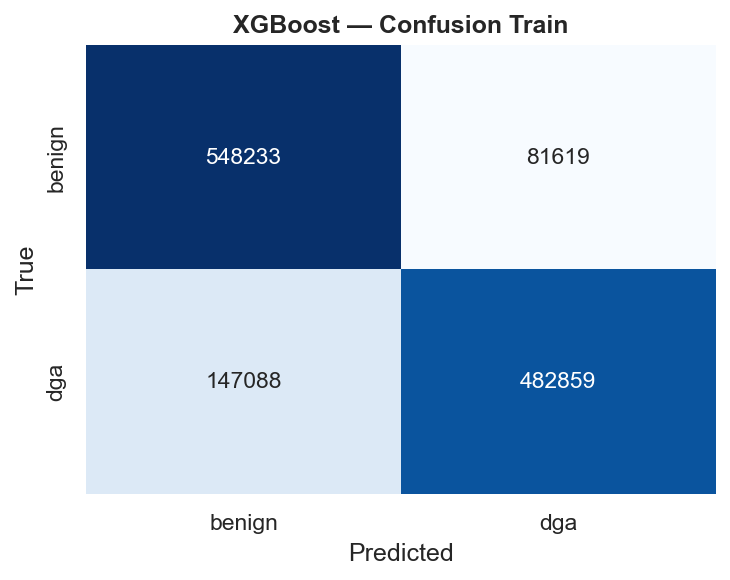

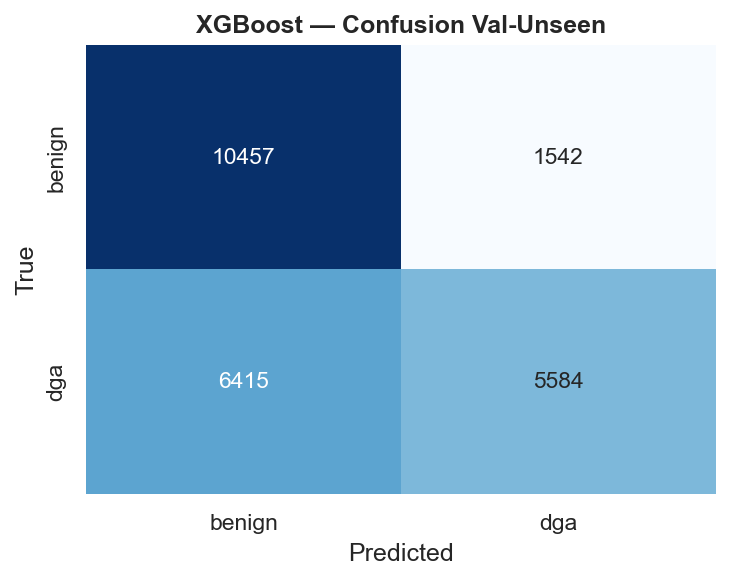

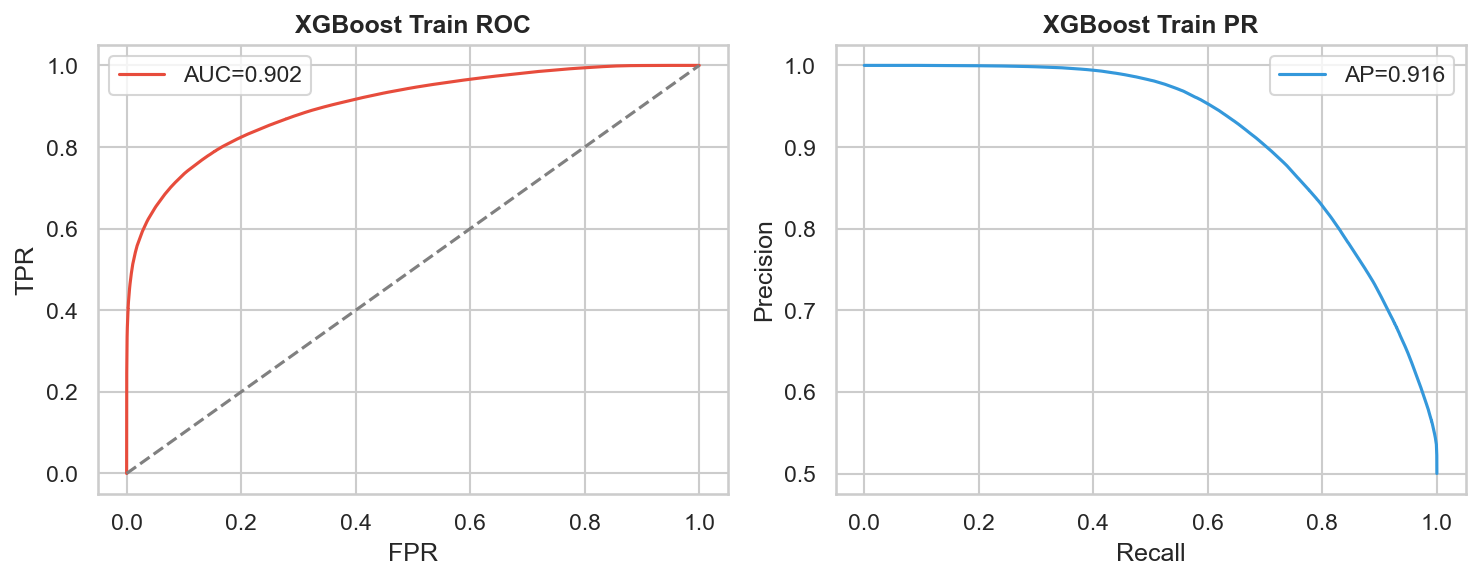

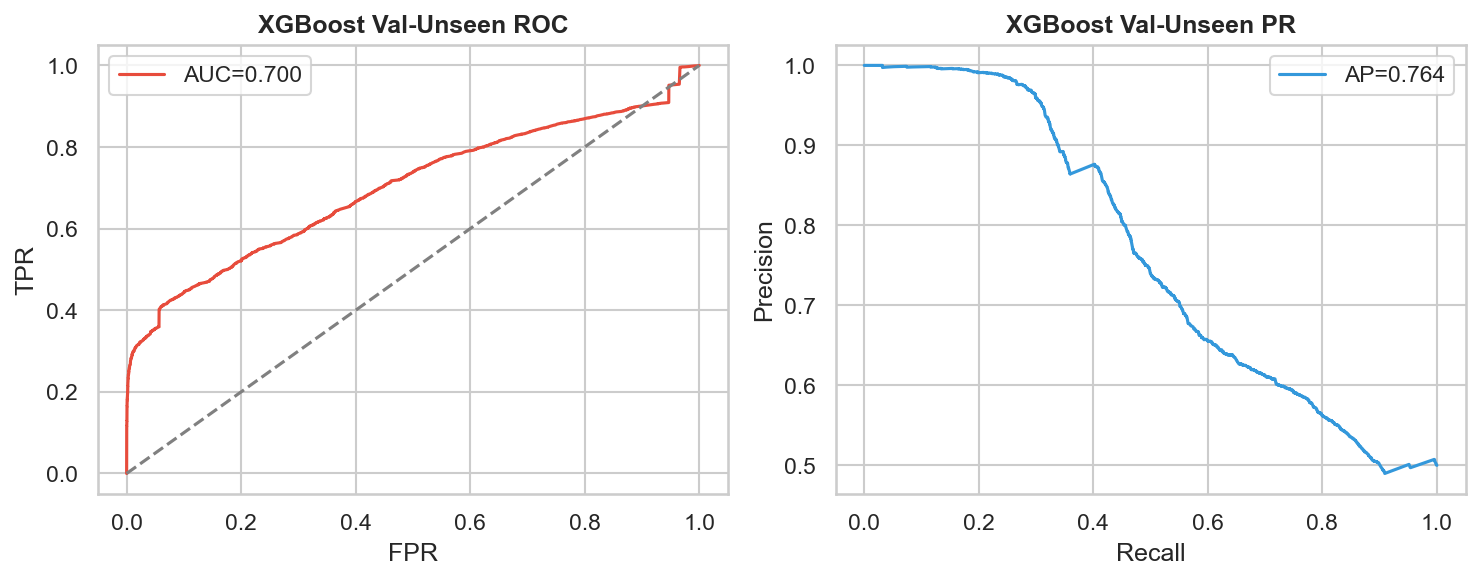

(0.699928750625599, 0.7639838295403398)

In [5]:

def plot_confusion(y_true, y_pred, title, path):
    cm=confusion_matrix(y_true, y_pred, labels=[0,1])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["benign","dga"], yticklabels=["benign","dga"])
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title, fontweight="bold")
    plt.tight_layout(); plt.savefig(path, bbox_inches="tight"); plt.show()
def plot_curves(y_true, y_proba, prefix, path):
    fpr,tpr,_=roc_curve(y_true, y_proba); auc=roc_auc_score(y_true, y_proba)
    prec,rec,_=precision_recall_curve(y_true, y_proba); ap=average_precision_score(y_true, y_proba)
    fig,axes=plt.subplots(1,2,figsize=(10,4))
    axes[0].plot(fpr,tpr,color="#e74c3c",label=f"AUC={auc:.3f}"); axes[0].plot([0,1],[0,1],color="gray",ls="--")
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title(f"{prefix} ROC",fontweight="bold"); axes[0].legend()
    axes[1].plot(rec,prec,color="#3498db",label=f"AP={ap:.3f}")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title(f"{prefix} PR",fontweight="bold"); axes[1].legend()
    plt.tight_layout(); plt.savefig(path, bbox_inches="tight"); plt.show()
    return auc, ap

y_pred_train=model.predict(X_train); y_proba_train=model.predict_proba(X_train)[:,1]
y_pred_val=model.predict(X_val); y_proba_val=model.predict_proba(X_val)[:,1]

for name, yt, yp, ypr in [("TRAIN", y_train, y_pred_train, y_proba_train), ("VAL-UNSEEN (6 new families)", y_val, y_pred_val, y_proba_val)]:
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(yt, yp, target_names=["benign","dga"], digits=3))
    print(f"Accuracy {accuracy_score(yt,yp):.4f} | F1 {f1_score(yt,yp):.4f} | ROC-AUC {roc_auc_score(yt,ypr):.4f} | PR-AUC {average_precision_score(yt,ypr):.4f}")

plot_confusion(y_train, y_pred_train, "XGBoost — Confusion Train", FIG_DIR/"xgb_confusion_train.png")
plot_confusion(y_val, y_pred_val, "XGBoost — Confusion Val-Unseen", FIG_DIR/"xgb_confusion_val.png")
plot_curves(y_train, y_proba_train, "XGBoost Train", FIG_DIR/"xgb_curves_train.png")
plot_curves(y_val, y_proba_val, "XGBoost Val-Unseen", FIG_DIR/"xgb_curves_val.png")


Per-family Val Recall:
bigviktor       n=2000  wordlist=True  recall 0.198
kraken          n=2000  wordlist=False  recall 0.421
legit           n=11999  benign-accuracy 0.871
manuelita       n=1999  wordlist=True  recall 0.146
ranbyus         n=2000  wordlist=False  recall 0.891
suppobox        n=2000  wordlist=True  recall 0.142
zeus-newgoz     n=2000  wordlist=False  recall 0.994

Checkpoint — val wordlist macro-recall 0.1617


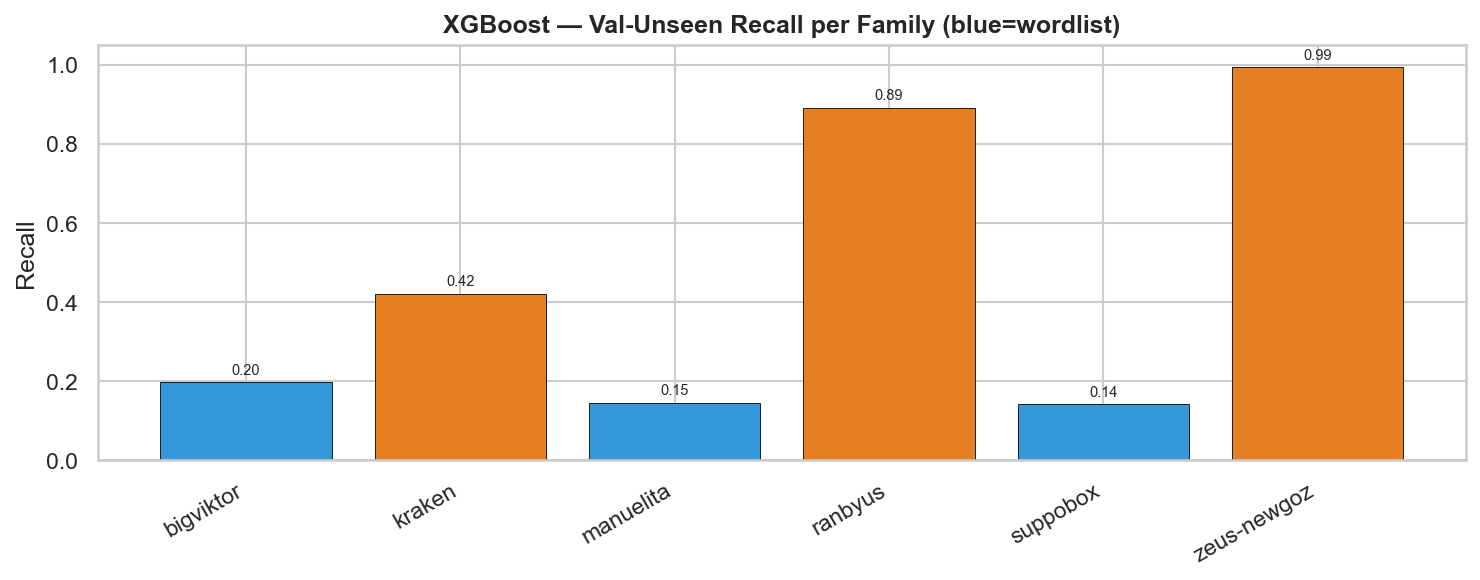

In [6]:

print("Per-family Val Recall:")
for fam in sorted(val["family"].unique()):
    mask=val["family"]==fam
    yt=y_val[mask]; yp=y_pred_val[mask]
    if fam=="legit":
        print(f"{fam:15s} n={len(yt):4d}  benign-accuracy {(yt==yp).mean():.3f}")
    else:
        print(f"{fam:15s} n={len(yt):4d}  wordlist={val.loc[mask,'wordlist'].iloc[0]}  recall {(yp==1).mean():.3f}")

wordlist_fams=["suppobox","bigviktor","manuelita"]
recs=[(y_pred_val[val["family"]==f]==1).mean() for f in wordlist_fams if (val["family"]==f).sum()>0]
print(f"\nCheckpoint — val wordlist macro-recall {np.mean(recs):.4f}")

fams=[f for f in sorted(val["family"].unique()) if f!="legit"]
recs=[(y_pred_val[val["family"]==f]==1).mean() for f in fams]
is_wl=[val[val["family"]==f]["wordlist"].iloc[0] for f in fams]
colors=["#3498db" if wl else "#e67e22" for wl in is_wl]
plt.figure(figsize=(10,4))
plt.bar(fams, recs, color=colors, edgecolor="black", linewidth=0.4)
plt.ylim(0,1.05); plt.ylabel("Recall"); plt.title("XGBoost — Val-Unseen Recall per Family (blue=wordlist)", fontweight="bold")
plt.xticks(rotation=30, ha="right")
for i,v in enumerate(recs): plt.text(i, v+0.02, f"{v:.2f}", ha="center", fontsize=7)
plt.tight_layout(); plt.savefig(FIG_DIR/"xgb_per_family_recall_val.png", bbox_inches="tight"); plt.show()



## 4. Feature Importance — XGBoost gain + permutation + SHAP


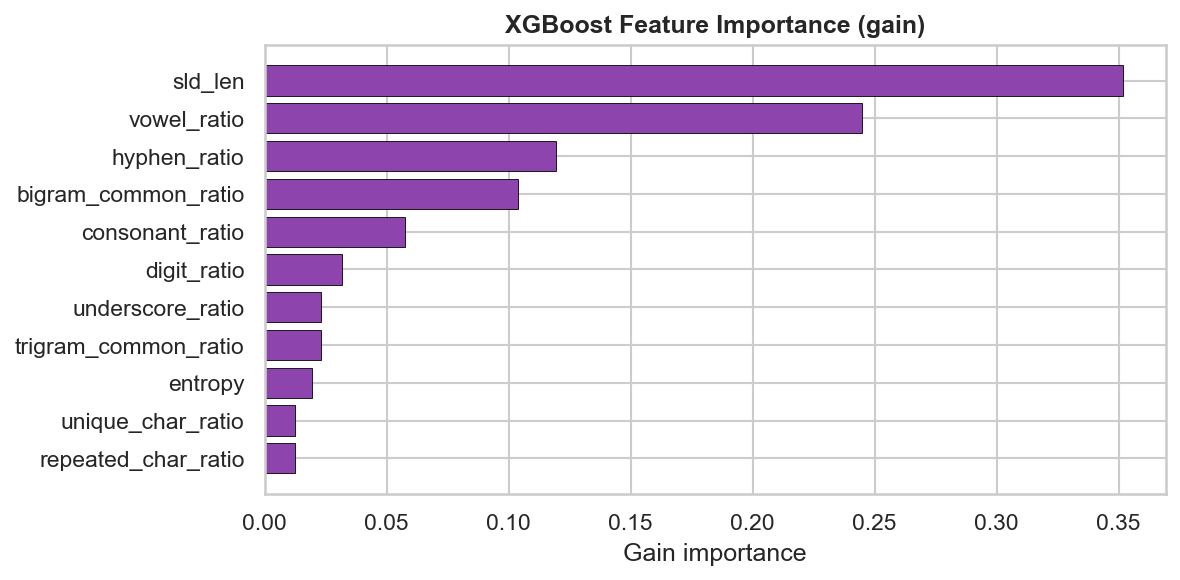

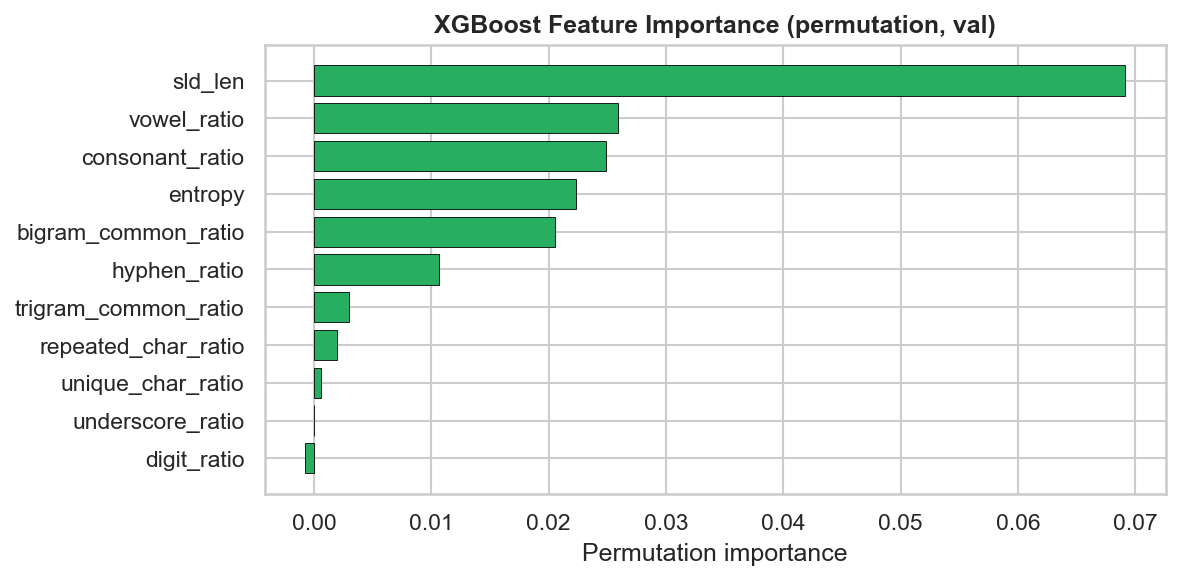

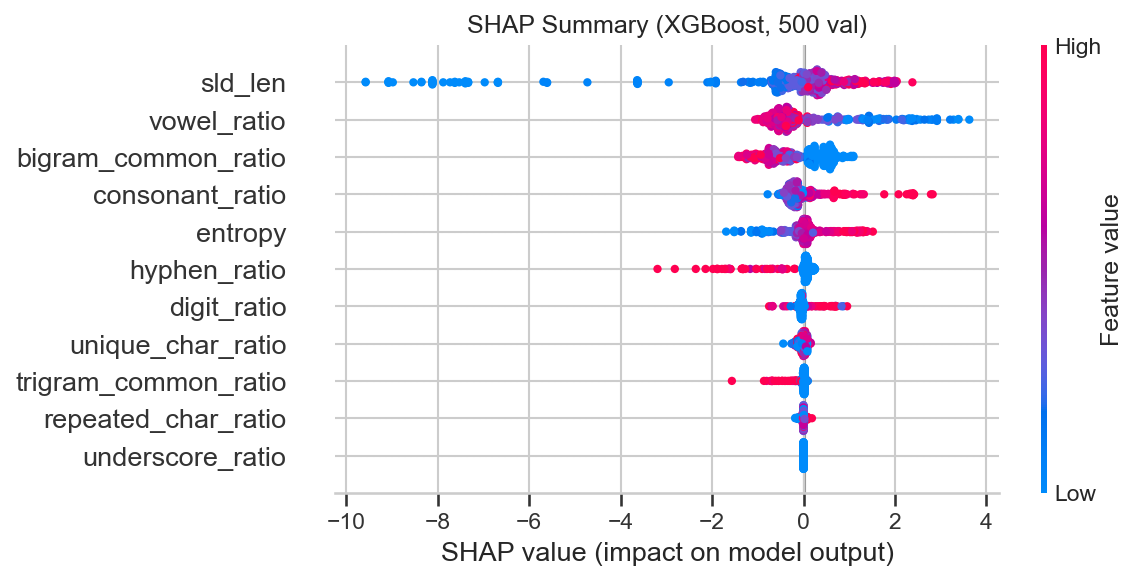

             feature   gain  permutation
             sld_len 0.3516       0.0691
         vowel_ratio 0.2450       0.0259
     consonant_ratio 0.0577       0.0249
             entropy 0.0193       0.0223
 bigram_common_ratio 0.1038       0.0206
        hyphen_ratio 0.1195       0.0107
trigram_common_ratio 0.0230       0.0029
 repeated_char_ratio 0.0125       0.0019
   unique_char_ratio 0.0125       0.0006
    underscore_ratio 0.0232      -0.0000
         digit_ratio 0.0318      -0.0007


In [7]:

# Gain importance (XGBoost)
imp=model.feature_importances_
order=np.argsort(imp)[::-1]
plt.figure(figsize=(8,4))
plt.barh([FEATURE_COLS[i] for i in order], imp[order], color="#8e44ad", edgecolor="black", linewidth=0.4)
plt.xlabel("Gain importance"); plt.title("XGBoost Feature Importance (gain)", fontweight="bold")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.savefig(FIG_DIR/"xgb_feature_gain.png", bbox_inches="tight"); plt.show()

# Permutation
perm=permutation_importance(model, X_val, y_val, n_repeats=10, random_state=SEED, n_jobs=-1)
perm_imp=perm.importances_mean
order=np.argsort(perm_imp)[::-1]
plt.figure(figsize=(8,4))
plt.barh([FEATURE_COLS[i] for i in order], perm_imp[order], color="#27ae60", edgecolor="black", linewidth=0.4)
plt.xlabel("Permutation importance"); plt.title("XGBoost Feature Importance (permutation, val)", fontweight="bold")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.savefig(FIG_DIR/"xgb_feature_permutation.png", bbox_inches="tight"); plt.show()

try:
    import shap
    explainer=shap.TreeExplainer(model)
    shap_vals=explainer.shap_values(X_val[:500])
    plt.figure()
    shap.summary_plot(shap_vals, X_val[:500], feature_names=FEATURE_COLS, show=False, plot_size=(8,4))
    plt.title("SHAP Summary (XGBoost, 500 val)"); plt.tight_layout()
    plt.savefig(FIG_DIR/"xgb_shap.png", bbox_inches="tight"); plt.show()
except Exception as e:
    print(f"SHAP skipped: {e}")

feat_df=pd.DataFrame({"feature":FEATURE_COLS, "gain":imp, "permutation":perm_imp}).sort_values("permutation", ascending=False)
print(feat_df.round(4).to_string(index=False))
feat_df.to_csv(BASE/"results/baselines/xgb_feature_importance.csv", index=False)



## 5. Save Best Weights & Metrics


In [8]:

import joblib, json
from pathlib import Path
metrics={
    "model":"xgboost",
    "train":{"acc":float(accuracy_score(y_train,y_pred_train)),"f1":float(f1_score(y_train,y_pred_train)),"auc":float(roc_auc_score(y_train,y_proba_train)),"ap":float(average_precision_score(y_train,y_proba_train))},
    "val":{"acc":float(accuracy_score(y_val,y_pred_val)),"f1":float(f1_score(y_val,y_pred_val)),"auc":float(roc_auc_score(y_val,y_proba_val)),"ap":float(average_precision_score(y_val,y_proba_val)),"wordlist_macro_recall":float(np.mean([(y_pred_val[val["family"]==f]==1).mean() for f in ["suppobox","bigviktor","manuelita"]]))},
    "per_family_val_recall":{f:float((y_pred_val[val["family"]==f]==1).mean()) for f in sorted(val["family"].unique()) if f!="legit"},
    "feature_cols":FEATURE_COLS, "use_gpu":USE_GPU
}
Path("results/baselines").mkdir(parents=True, exist_ok=True)
with open("results/baselines/xgb_metrics.json","w") as f: json.dump(metrics,f,indent=2)
joblib.dump({"model":model, "feature_cols":FEATURE_COLS}, WEIGHTS_DIR/"xgb_best.pkl")
joblib.dump({"model":model, "feature_cols":FEATURE_COLS}, BASE/"results/baselines/xgb_best.pkl")
print(f"Saved to {WEIGHTS_DIR/'xgb_best.pkl'}")
print(json.dumps(metrics,indent=2))


Saved to G:\dga_killer\training\weights\xgb_best.pkl
{
  "model": "xgboost",
  "train": {
    "acc": 0.8184575475929097,
    "f1": 0.8085212549971744,
    "auc": 0.9015051657098194,
    "ap": 0.9164932328739475
  },
  "val": {
    "acc": 0.6684307025585465,
    "f1": 0.5839477124183007,
    "auc": 0.699928750625599,
    "ap": 0.7639838295403398,
    "wordlist_macro_recall": 0.1616909287977322
  },
  "per_family_val_recall": {
    "bigviktor": 0.1975,
    "kraken": 0.4215,
    "manuelita": 0.1455727863931966,
    "ranbyus": 0.8915,
    "suppobox": 0.142,
    "zeus-newgoz": 0.994
  },
  "feature_cols": [
    "sld_len",
    "entropy",
    "digit_ratio",
    "hyphen_ratio",
    "underscore_ratio",
    "vowel_ratio",
    "consonant_ratio",
    "bigram_common_ratio",
    "trigram_common_ratio",
    "unique_char_ratio",
    "repeated_char_ratio"
  ],
  "use_gpu": true
}



## Conclusion

XGBoost trained on train only, validated on 6 new families. All curves/matrices for train & val are above. Feature importance (gain/permutation/SHAP) shows which lexical numbers matter — teacher can see `entropy`/`length` on top. Best weights frozen for final test.
